In [1]:
from sklearnex import patch_sklearn
# Reimplementations of sklearn functions with optimization for speed
patch_sklearn(global_patch=True)
from sklearn.decomposition import TruncatedSVD
# from sklearn.mixture import GaussianMixture
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import GridSearchCV
import numpy as np
import pickle
# from sklearn.linear_model import LogisticRegression
# from scipy.stats import norm
# from scipy.stats.mstats import gmean
import matplotlib.pyplot as plt
# import stepmix
from sklearn import svm
import seaborn as sns; sns.set()
import pandas as pd
from matplotlib.collections import QuadMesh
from matplotlib.text import Text
import random

Scikit-learn was successfully globally patched by Intel(R) Extension for Scikit-learn


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/gene_expression_tabsap','rb') as file:
#         gex_matrix = pickle.load(file)
#         gex_matrix = gex_matrix.transpose()

with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/bladder_adt_predictions_for_tabsap','rb') as file:
        adt_predictions = pickle.load(file)

with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/bladder_tabsap_annotations','rb') as file:
        annotations = pickle.load(file)

# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/tsvd_projector_from_3tmodel','rb') as file:
#         tsvd_v = pickle.load(file)

# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/gex_filtered_for_tsvd','rb') as file:
#         gex_filtered = pickle.load(file)

# Keep csc since it uses only about 1/10th of memory compared to array
# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/gene_expression_tabsap_normed_filtered','rb') as file:
#         gex_normed_filtered = pickle.load(file)

with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/bladder_gene_expression_tabsap_normed','rb') as file:
        gex_normed = pickle.load(file)

# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/gene_expression_tabsap_normed','rb') as file:
#         gex_normed_blood = pickle.load(file)

# with open('C:/Users/mz24b548/Documents/GitRepos_local/scLinear_R/Tabula_sapiens_classifier_input/tabsap_annotations','rb') as file:
#         annotations_blood = pickle.load(file)ue



In [3]:
# rnd_ordering = np.arange(gex_normed.shape[0])
# np.random.shuffle(rnd_ordering)

# train_indices = rnd_ordering[0:int(0.75*gex_normed.shape[0])+1] #end not included which is why end of range here = start of range next
# test_indices = rnd_ordering[(int(0.75*gex_normed.shape[0])+1):(gex_normed.shape[0])]



In [4]:
# Make sure train set contains at least 20 of each cell type (but at most 80% so there's some left for test) --> smallest group contains 23
gex_normed = gex_normed.transpose()
annot = pd.Series(annotations)
train_size = 5000
min_sample_per_cell = annot.groupby(annot).apply(lambda x: x.sample(min(int(0.8 *x.size),20), random_state=1))
train_indices = set(min_sample_per_cell.index.get_level_values(1))
rest = set(annot.index).difference(train_indices)
train_indices = train_indices.union(set(random.sample(list(rest),train_size-len(train_indices))))
test_indices = set(annot.index).difference(train_indices)
train_indices = list(train_indices)
test_indices = list(test_indices)
#TODO: ensure that when selecting rest at random, it doesn't now reduce test samples past a minimum threshold either

In [5]:
test_indices = random.sample(test_indices,5000)

In [6]:
# from cProfile import Profile
# from pstats import SortKey, Stats
# with Profile() as profile:
#     nonemptyrow = gex_normed_filtered.any(axis = 1)
#     (
#         Stats(profile)
#         .strip_dirs()
#         .sort_stats(SortKey.CALLS)
#         .print_stats()
#     )

In [7]:
# csc_minor_stored_values = np.bincount(gex_normed_filtered.indices, minlength=gex_normed_filtered.shape[0])
# keep_rows = np.where(csc_minor_stored_values)[0]
# gex_normed_filtered = gex_normed_filtered[keep_rows,]
# gex_normed_filtered = gex_normed_filtered.transpose()

# csc_minor_stored_values = np.bincount(gex_normed.indices, minlength=gex_normed.shape[0])
# keep_rows = np.where(csc_minor_stored_values)[0]
# gex_normed = gex_normed[keep_rows,]
# gex_normed = gex_normed.transpose()
# No empty cols / droplets --> probably already filtered before

In [8]:
# # Time used scales exponentially (apparently min(nm^2,n^2m)) 
# # --> does seem to indeed not take much longer if i increase feature number but increases strongly with number of samples
# import time
# duration = []
# calc_at = [100,500,1000,2000,3000,10000]
# for rows_considered in calc_at:
#     print(rows_considered)
#     gex_projector = TruncatedSVD(300)
#     stime = time.time()
#     gex_projector.fit_transform(gex_normed[0:rows_considered,:])
#     etime = time.time()
#     duration.append(etime-stime)
# x2,x,o = np.polyfit(calc_at,duration,2)
# xs,o2 = np.polyfit(calc_at,duration,1)
# from math import log
# # plt.scatter(([log(i) for i in [100,500,1000,3000,5000,10000]]),[log(i) for i in duration])
# plt.scatter(calc_at,duration)
# xref = [i for i in range(max(calc_at))]
# yref = [x2*i**2+x*i+o for i in xref]
# yref2 = [xs*i+o2 for i in xref]
# plt.plot(xref,yref,ls = '-',color = 'red')
# plt.plot(xref,yref2,ls = '-',color = 'green')

In [9]:
# gex_projector = TruncatedSVD(n_components = 300)
# gex_projector.fit(gex_normed_filtered[train_indices,:][0:10000,:])

In [10]:
# gex_projector_full = TruncatedSVD(300)
# gex_projector_full.fit(gex_normed[train_indices,:][0:10000,])

In [11]:
# gex_projected = gex_projector.transform(gex_normed_filtered)
# gex_full_projected = gex_projector_full.transform(gex_normed)

In [12]:
# categories = {}
# for n,c in enumerate(np.unique(annotations)):
#     categories[c] = n
# colors = [categories[e] for e in annotations]
# plt.scatter(gex_full_projected[:,0],gex_full_projected[:,1],c = colors)

In [13]:
# parameters = {'kernel':('linear', 'rbf'), 'C':[1, 10]}
# svc = svm.SVC(cache_size= 1000)
# svc.fit(gex_full_projected[train_indices,:],np.array(annotations)[train_indices])
# clf = GridSearchCV(svc, parameters,verbose = 2)
# clf.fit(gex_projected[train_indices,:],np.array(annotations)[train_indices])

In [14]:
# takes about 10 minutes --> could try intel extension for sklearn which claims to reimplemented sklearn with optimization
# train_predictions = svc.predict(gex_projected[train_indices,:])
# Not a massive difference whether i do svd on only the genes considered by 3tmodel or all genes measured --> accuracy of about 90%
# test_predictions = svc.predict(gex_full_projected[test_indices,:])
# correct = sum(test_predictions == np.array(annotations)[test_indices])
# wrong = sum(test_predictions != np.array(annotations)[test_indices])
# accuracy = correct/(wrong+correct)
# print('{acc:.2f}% of labels in testset correctly assigned based on dimensionality reduced gene expression'.format(acc = 100*(accuracy)))

In [15]:
svc_adt = svm.SVC(cache_size = 4000)
svc_adt.fit(adt_predictions[train_indices,:],np.array(annotations)[train_indices])

SVC(cache_size=4000)

In [16]:
test_predictions_adt = svc_adt.predict(adt_predictions[test_indices,:])
correct = sum(test_predictions_adt == np.array(annotations)[test_indices])
wrong = sum(test_predictions_adt != np.array(annotations)[test_indices])
accuracy = correct/(wrong+correct)
print('{acc:.2f}% of labels in testset correctly assigned based on predicted ADT'.format(acc = 100*(accuracy)))

92.02% of labels in testset correctly assigned based on predicted ADT


In [17]:
import time
svc_full_gene= svm.SVC(cache_size = 4000)
stime = time.time()
svc_full_gene.fit(gex_normed[train_indices,:],np.array(annotations)[train_indices])
etime = time.time()
print(etime-stime)

132.75882363319397


In [33]:
# Also about 90-91% accurate without dimensionality reduction (for blood data)
test_predictions_gene_full = svc_full_gene.predict(gex_normed[test_indices,:])
correct = sum(test_predictions_gene_full == np.array(annotations)[test_indices])
wrong = sum(test_predictions_gene_full != np.array(annotations)[test_indices])
accuracy = correct/(wrong+correct)
print('{acc:.2f}% of labels in testset correctly assigned based on full gene expression'.format(acc = 100*(accuracy)))

94.30% of labels in testset correctly assigned based on full gene expression


In [34]:
dat = {
    'predicted' : test_predictions_gene_full,
    'annotation': np.array(annotations)[test_indices]
}
df = pd.DataFrame(dat)
tab = pd.crosstab(df['predicted'],df['annotation'],margins = True)
tab.dtype = int

dat = {
    'predicted' : test_predictions_adt,
    'annotation': np.array(annotations)[test_indices]
}
df = pd.DataFrame(dat)
tab_adt = pd.crosstab(df['predicted'],df['annotation'],margins = True)
tab_adt.dtype = int

In [35]:
# order =  [
#   #   "hematopoietic precursor cell"\
#   # ,"hematopoietic stem cell"\
#   # ,"common myeloid progenitor"\
#   "CD4-positive, alpha-beta T cell"\
#   # ,"naive thymus-derived CD4-positive, alpha-beta T cell"\
#   ,"CD8-positive, alpha-beta T cell"\
#   # ,"mature NK T cell"\
#   # ,"regulatory T cell"\
#   ,"monocyte"\
#   ,"classical monocyte"\
#   ,"intermediate monocyte"\
#   ,"non-classical monocyte"\
#   ,"erythrocyte"\
#   # ,"platelet"\
#   # ,"macrophage"\
#   # ,"B cell"\
#   # ,"natural killer cell"\
#   # ,"basophil"\
#   # ,"neutrophil"\
#   # ,"myeloid dendritic cell"\
#   # ,"plasmacytoid dendritic cell"\
#   # ,"plasma cell"\
#   ,"All"                
#          ]

# #drop emtpy rows and columns
# # row_order = []
# # col_order = []
# # for t in order:
# #     if t in tab.index:
# #         row_order.append(t)
# #     if t in tab.columns:
# #         col_order.append(t)
# to_plot = tab.reindex(order)[order].fillna(0).astype(int)
# to_plot_adt = tab_adt.reindex(order)[order].fillna(0).astype(int)

KeyError: "['classical monocyte', 'intermediate monocyte', 'non-classical monocyte'] not in index"

In [47]:
tab = tab.reindex(tab.columns).fillna(0).astype(int)
tab_adt = tab_adt.reindex(tab_adt.columns).fillna(0).astype(int)

In [55]:
def plot_crosstab(ctab,title):
    # fig = plt.figure(num=None, figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')
    fig = plt.figure(figsize = (20,20))
    
    plt.clf()
    ax = fig.add_subplot(111)
    ax.set_aspect(1)
    res = sns.heatmap(ctab, annot=True,vmin= 0,vmax = 20,annot_kws={"fontsize":16},fmt='d',cbar = False)
    quadmesh = ax.findobj(QuadMesh)[0]
    facecolors = quadmesh.get_facecolors()
    facecolors = facecolors.reshape((ctab.shape[0],ctab.shape[1],4))
    facecolors[:,ctab.shape[1]-1,:] = np.ones((ctab.shape[1],4))
    facecolors[ctab.shape[0]-1,:,:] = np.ones((ctab.shape[0],4))

    # plt.title('How to plot a coningency table with python \n using matplotlib and seaborn ?',fontsize=12)
    ax.pcolormesh(facecolors)
    for i in ax.findobj(Text):
        i.set_color('black')
    plt.xticks(fontsize = 20,rotation = 90)
    plt.yticks(fontsize = 20, rotation = 0)
    plt.xlabel('Annotation')
    plt.ylabel('Prediction')
    plt.savefig(title+".png", bbox_inches='tight', dpi=100)
    
    plt.show()

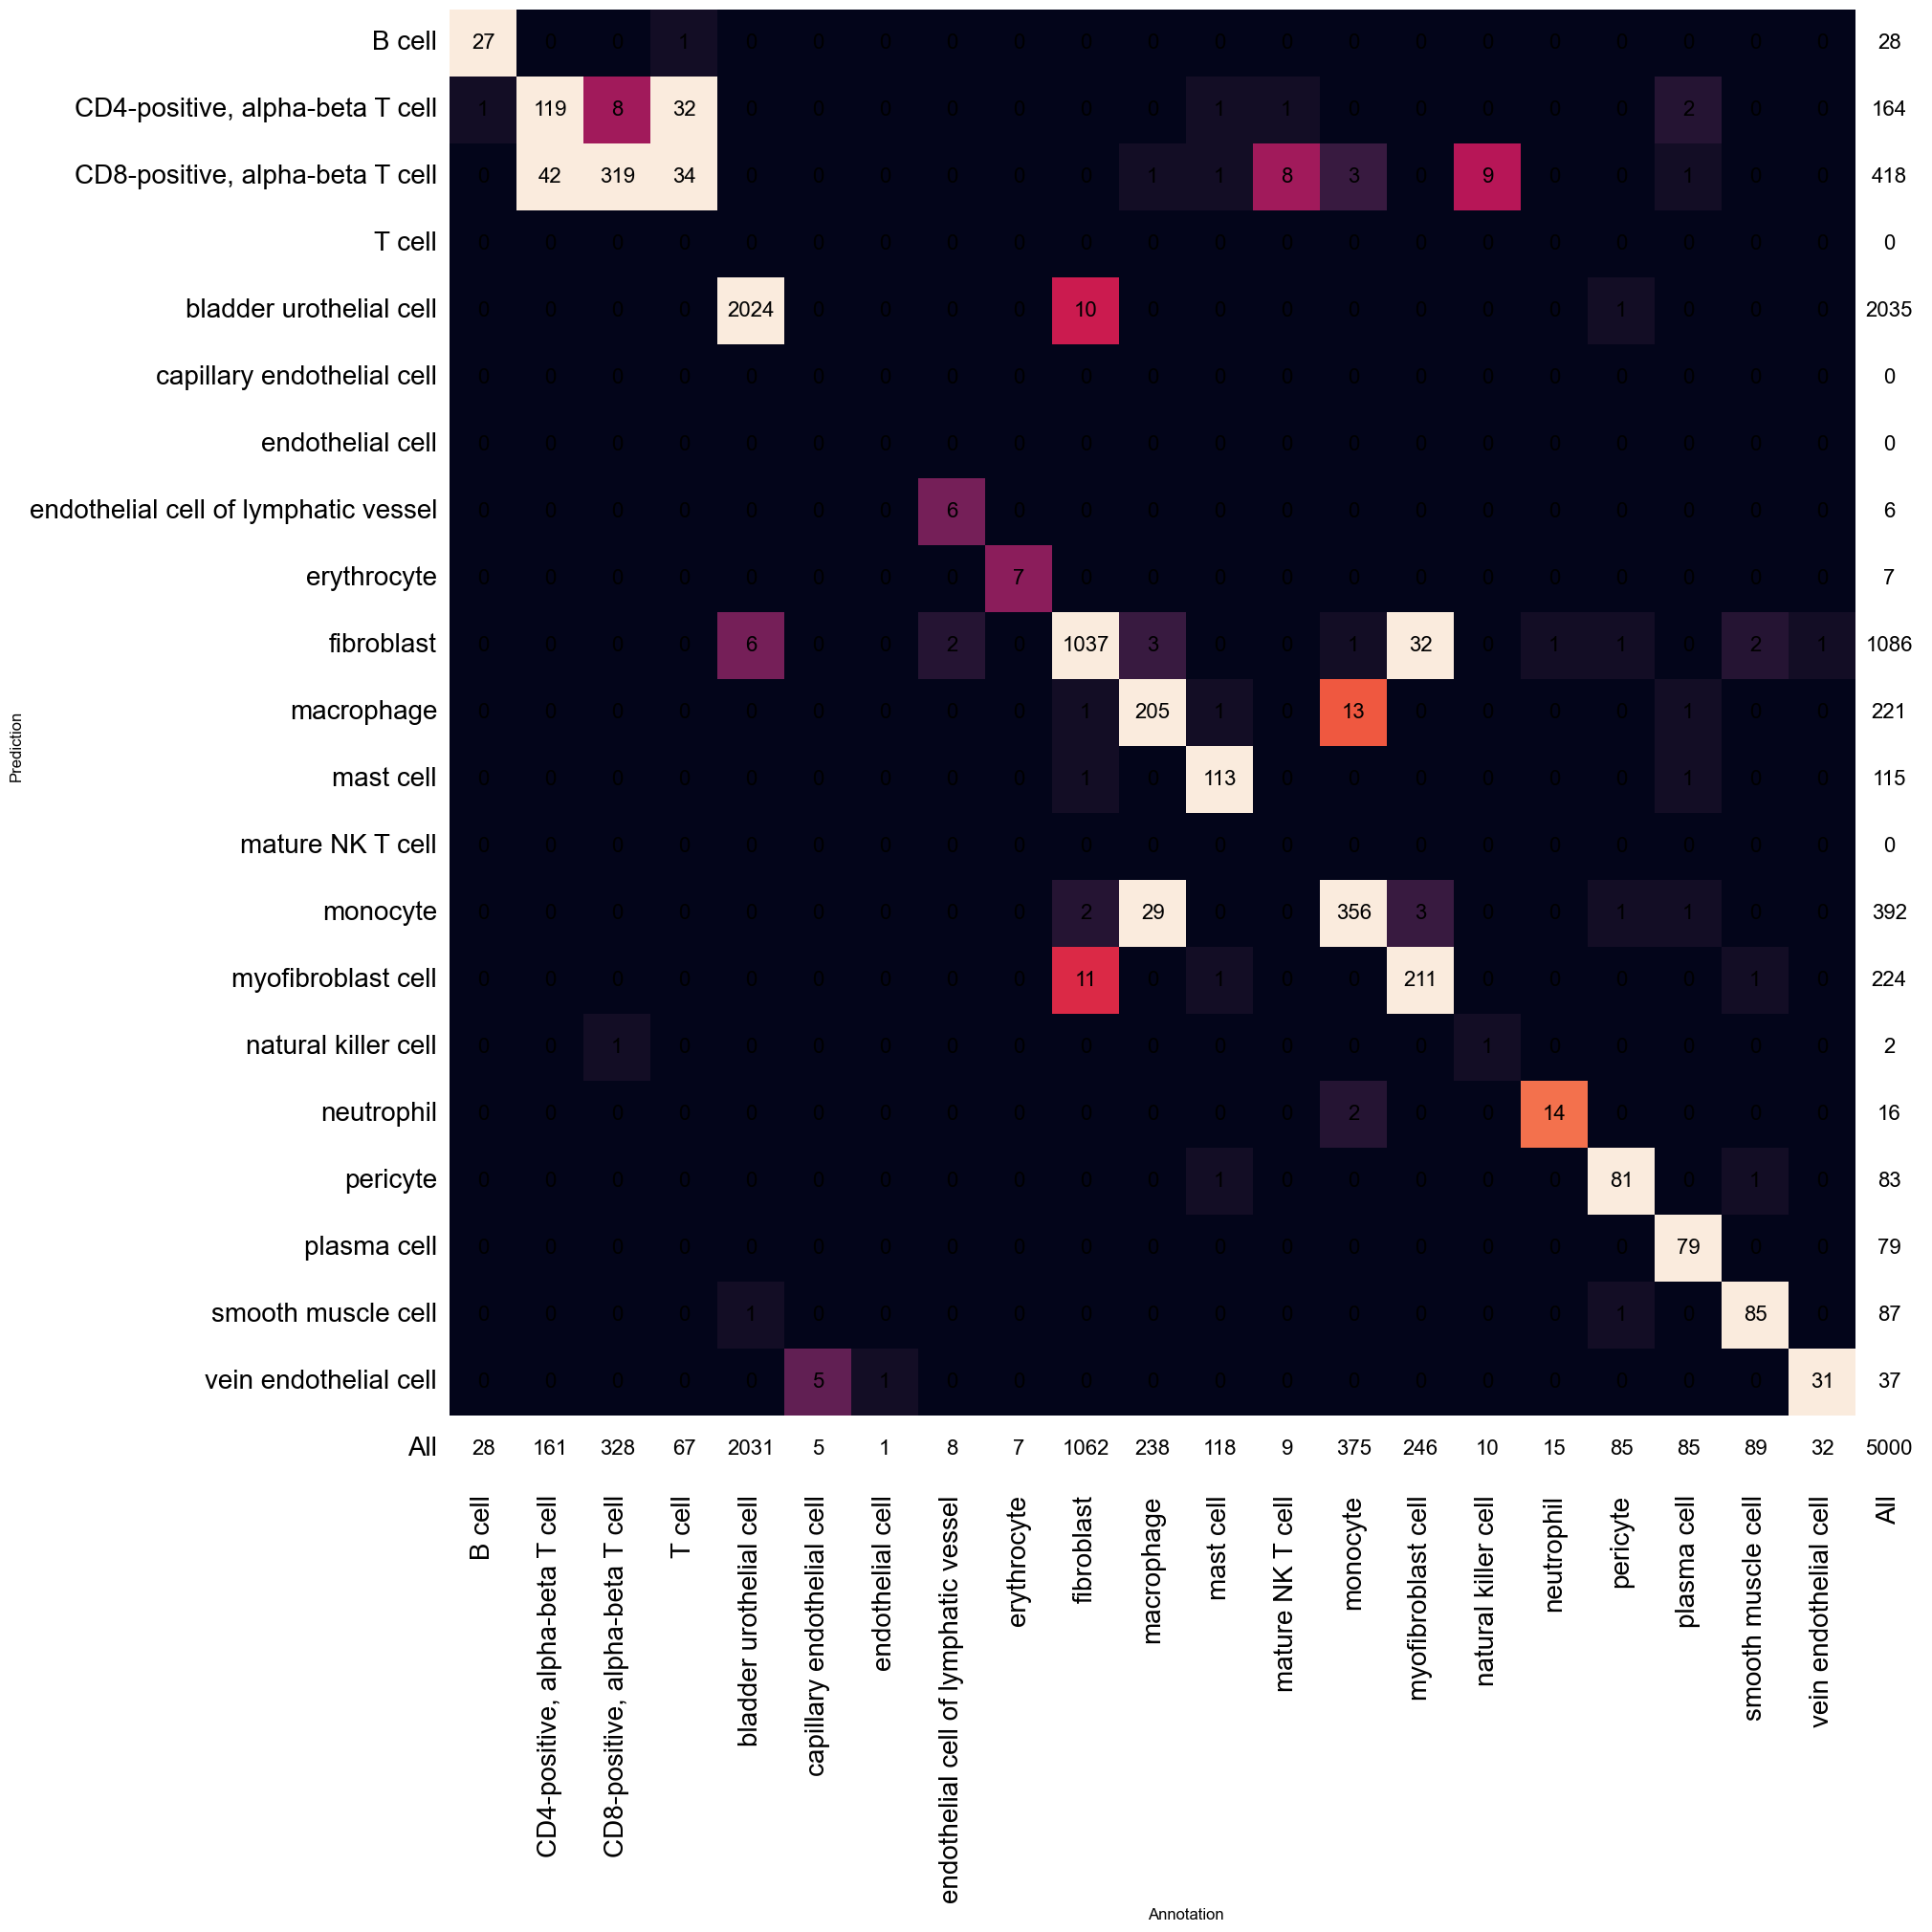

In [56]:
plot_crosstab(tab,'gene based classification')

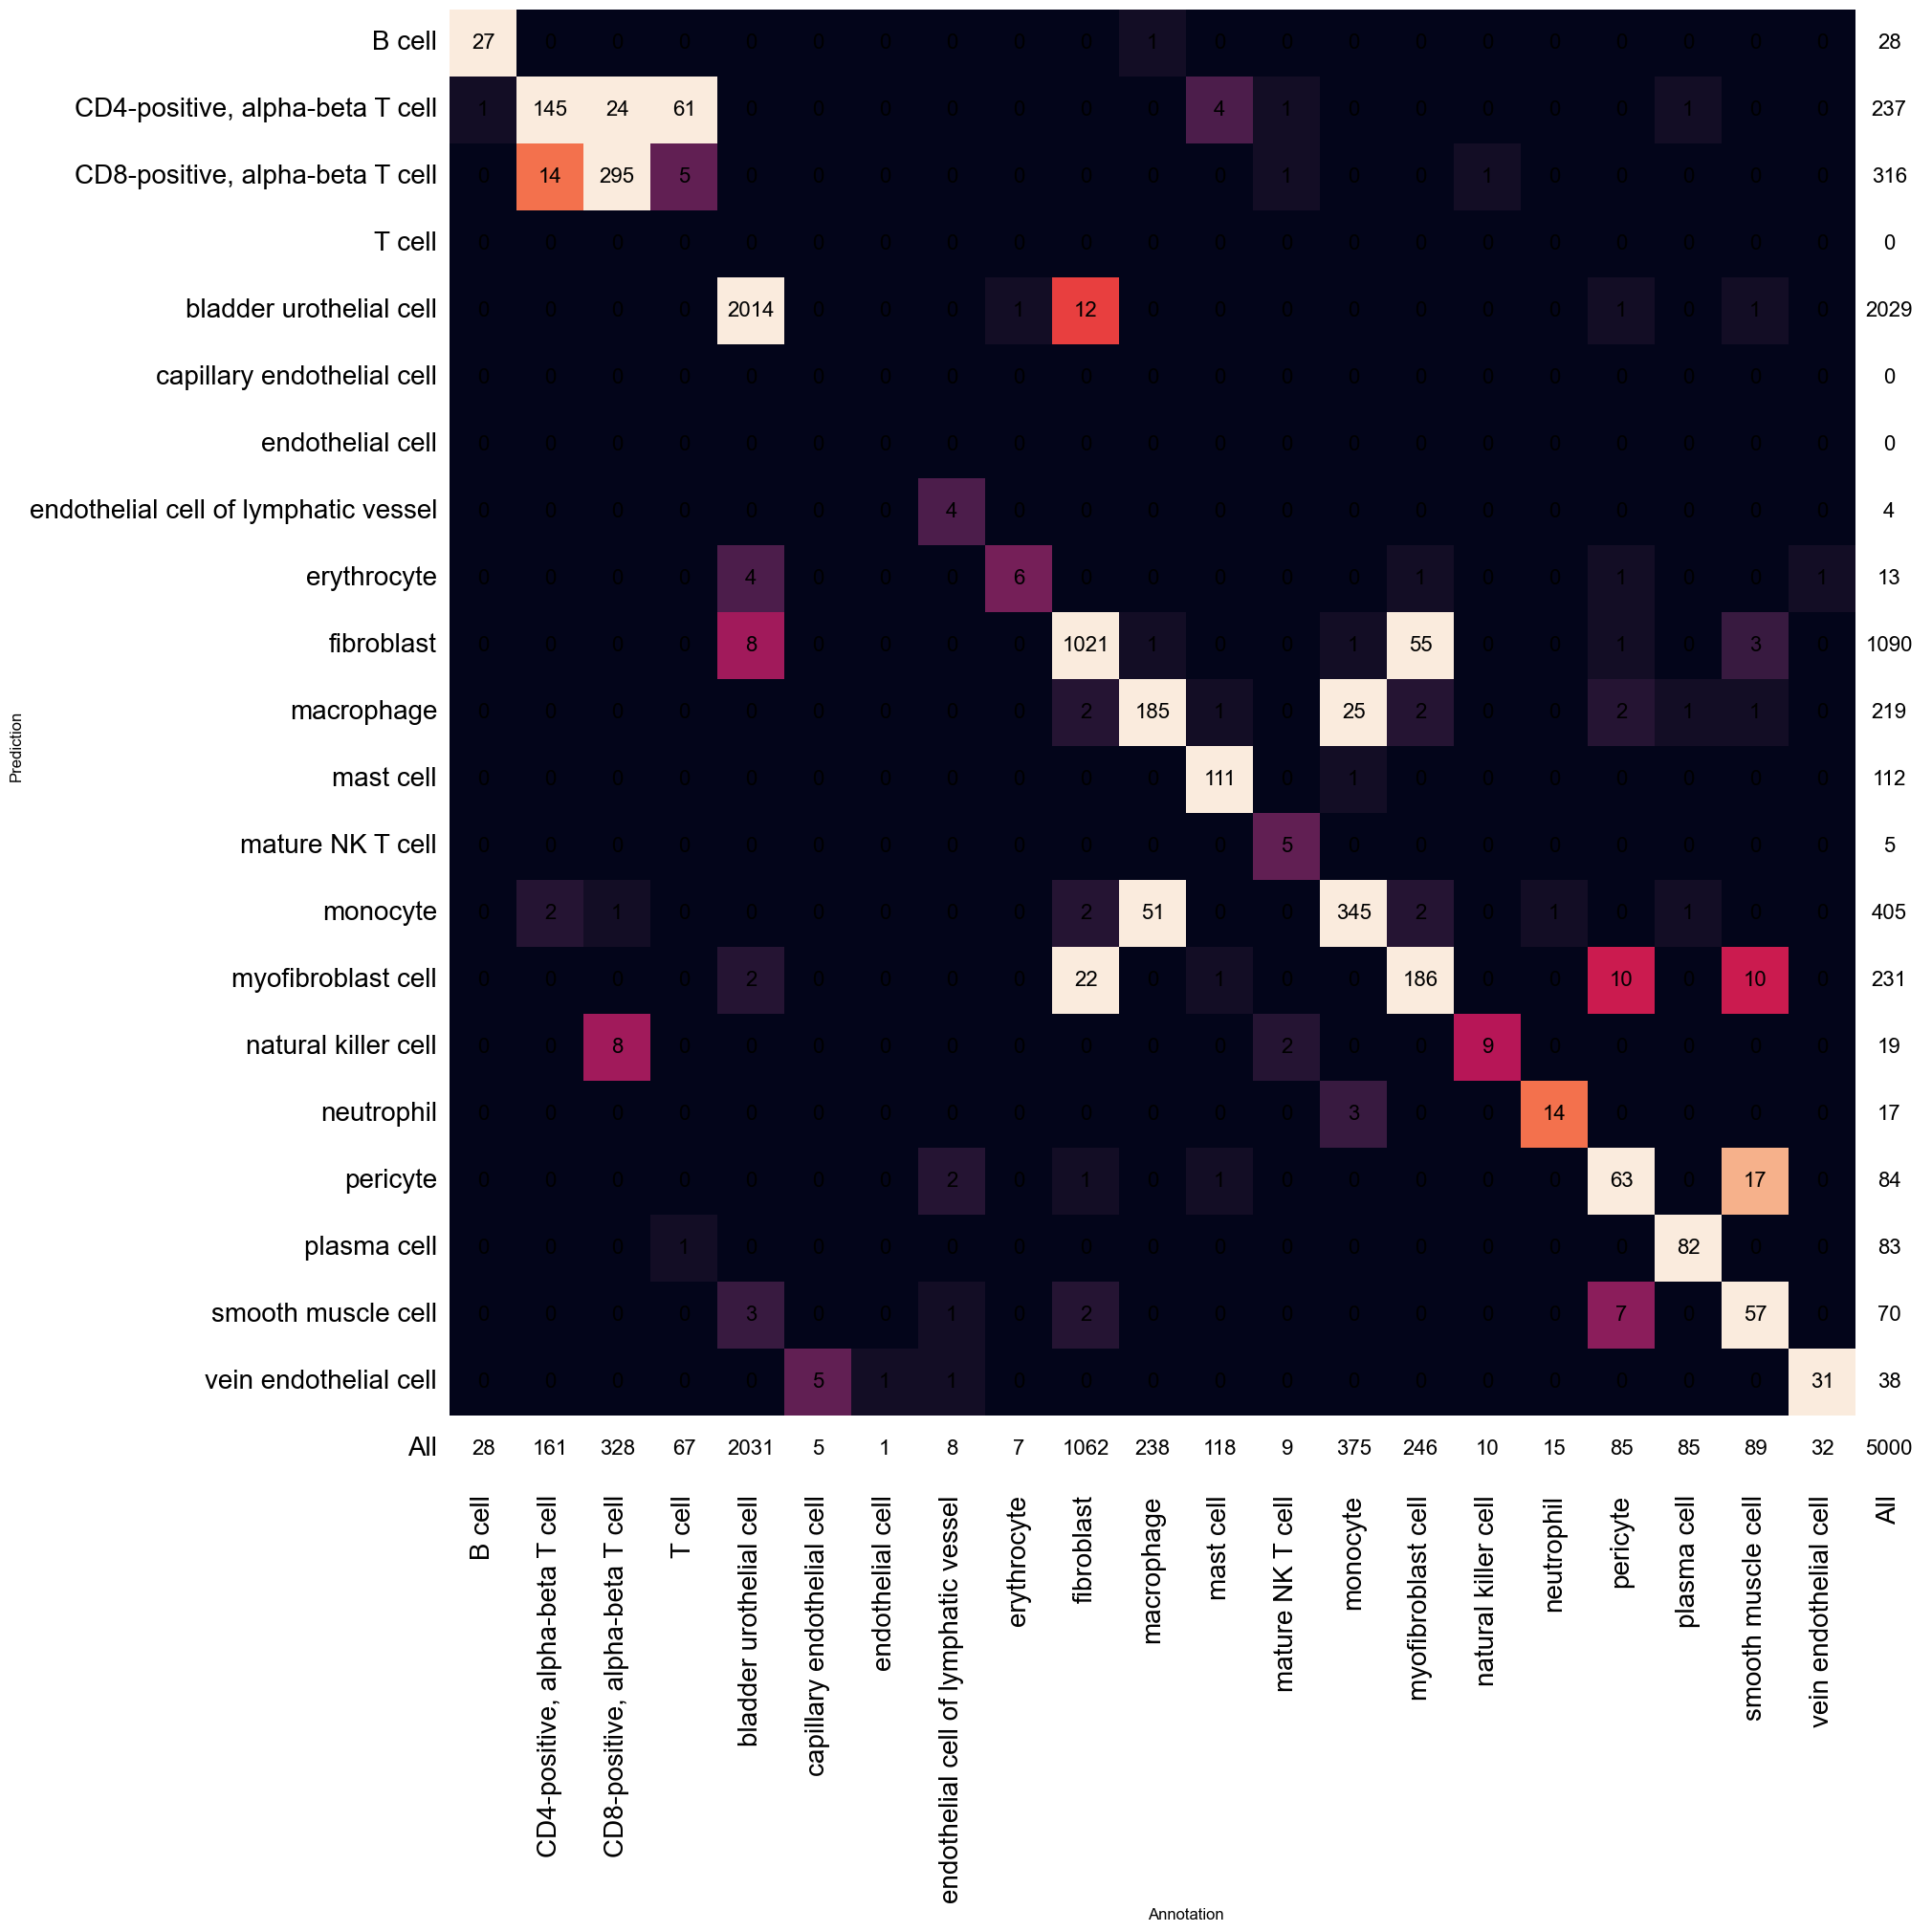

In [57]:
plot_crosstab(tab_adt,'adt based classification')

annotation,B cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta T cell",T cell,bladder urothelial cell,capillary endothelial cell,endothelial cell,endothelial cell of lymphatic vessel,erythrocyte,fibroblast,...,mature NK T cell,monocyte,myofibroblast cell,natural killer cell,neutrophil,pericyte,plasma cell,smooth muscle cell,vein endothelial cell,All
annotation,,,,,,,,,,,,,,,,,,,,,
B cell,27,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
"CD4-positive, alpha-beta T cell",1,119,8,32,0,0,0,0,0,0,...,1,0,0,0,0,0,2,0,0,164
"CD8-positive, alpha-beta T cell",0,42,319,34,0,0,0,0,0,0,...,8,3,0,9,0,0,1,0,0,418
T cell,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
bladder urothelial cell,0,0,0,0,2024,0,0,0,0,10,...,0,0,0,0,0,1,0,0,0,2035
capillary endothelial cell,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
endothelial cell,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
endothelial cell of lymphatic vessel,0,0,0,0,0,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,6
erythrocyte,0,0,0,0,0,0,0,0,7,0,...,0,0,0,0,0,0,0,0,0,7
